GridProblem self-check passed.


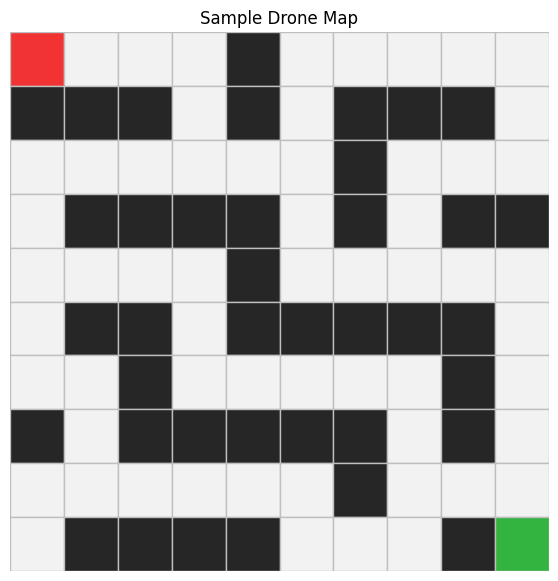

Visualized Solution Paths


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,16
3,IDS,success,NaN,18.0,18.0,55,19,55


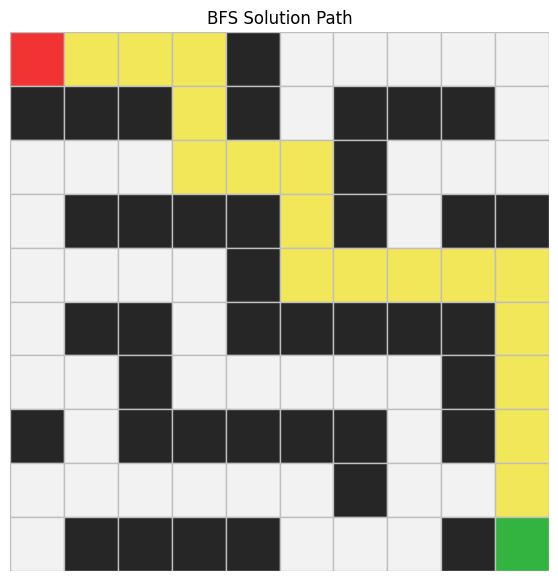

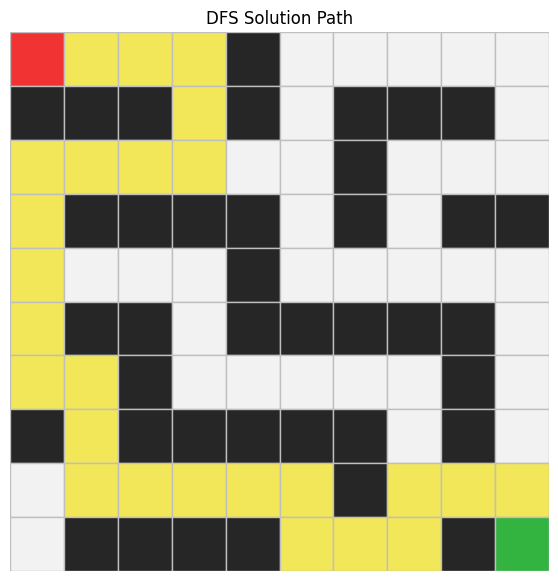

Results for Grid 1


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,26.0,26.0,46,3,46
1,DFS,success,NaN,26.0,26.0,45,3,47
2,DLS,cutoff,12.0,NaN,NaN,23,13,23
3,IDS,cutoff,NaN,NaN,NaN,0,13,0


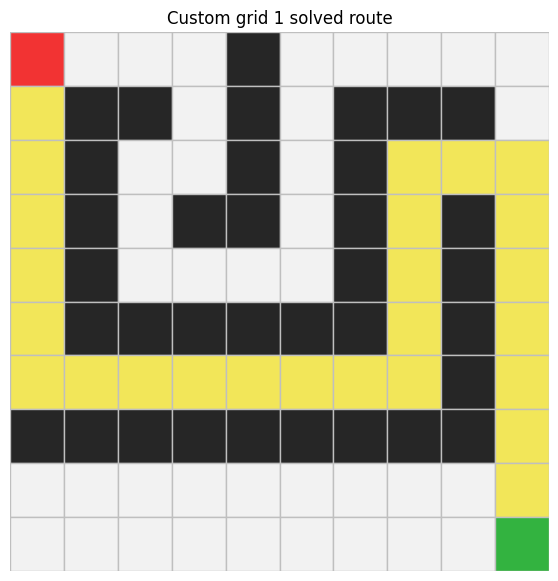


Large Scale Grid


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,86.0,86.0,111,4,113
1,DFS,success,NaN,86.0,86.0,120,8,126
2,DLS,cutoff,12.0,NaN,NaN,36,13,36
3,IDS,cutoff,NaN,NaN,NaN,0,13,0


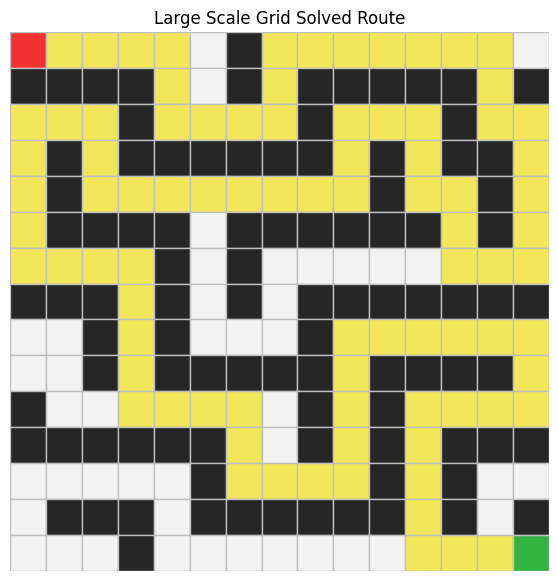

In [14]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# 2. The Abstract Problem Interface

class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass


# 3. The Node Class & Search Results Dataclasses

@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost



# 4. Helper Functions

def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """Return True if state already appears on the path from the root to node."""
    while node is not None:
        if node.state == state:
            return True
        node = node.parent
    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])


# 5. Implementing the Grid Search Problem

MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # Verify if the current drone position coordinate tuple directly matches our destination goal
        #Todo 1
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        #TODO 2:
        # Return a list of legal action names
        legal_actions = []
        row, col = state
        
        for action_name, (dr, dc) in MOVES.items():
            neighbor_state = (row + dr, col + dc)
            
            # Bound and obstacle constraints verification checkpoint
            if self.in_bounds(neighbor_state):
                if self.is_free(neighbor_state):
                    legal_actions.append(action_name)
                    
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        #TODO 3:
        # Apply vector transformations cleanly to determine the resulting coordinates
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        #TODO 4:
        #Simple unweighted grid
        return 1.0

# Test For Grid Problem
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

# 7. Visualisation Helper 

def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)  # Dark Charcoal color for solid obstacles
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)  # Distinct red for start location
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)  # Safe distinct green for goal point
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)  # Yellow highlights to map solution traces
            else:
                fill = (0.95, 0.95, 0.95)  # Clean light gray for traversable territory

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()



# 6. Sample Drone Map 


sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)
plot_path(sample_grid, start, goal, title="Sample Drone Map")


# 8. The Shared expand Method

class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        current_state = node.state
        for action in problem.actions(current_state):
            next_state = problem.result(current_state, action)
            step_cost = problem.action_cost(current_state, action, next_state)
            yield Node(
                state=next_state,
                parent=node,
                action=action,
                path_cost=node.path_cost + step_cost
            )

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass
    
# 9. Breadth-First Search (BFS)

class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
        expanded = 0
        max_frontier = 0
    # 1. Create the initial node from problem.initial_state().
        start_state = problem.initial_state()
        start_node = Node(start_state)
        
    # 2. If the initial state is the goal, return success early.    
        if problem.is_goal(start_state):
            return SearchResult(algorithm, "success", start_node, 0, 1, 1)
            
        frontier = deque([start_node])
        reached = {start_state}
        
        while len(frontier) > 0:
            if len(frontier) > max_frontier:
                max_frontier = len(frontier)
                
            node = frontier.popleft()
            expanded += 1
            
            for child in self.expand(problem, node):
                s = child.state
                
                if problem.is_goal(s):
                    if len(frontier) > max_frontier:
                        max_frontier = len(frontier)
                    return SearchResult(algorithm, "success", child, expanded, max_frontier, len(reached))
                    
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
                    
        return SearchResult(algorithm, "failure", None, expanded, max_frontier, len(reached))


# 10. Depth-First Search (DFS)

class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        expanded = 0
        max_frontier = 0
        
        start_state = problem.initial_state()
        start_node = Node(start_state)
        
        if problem.is_goal(start_state):
            return SearchResult(algorithm, "success", start_node, 0, 1, 1)
            
        frontier = [start_node]
        reached = {start_state}
        
        while len(frontier) > 0:
            if len(frontier) > max_frontier:
                max_frontier = len(frontier)
                
            node = frontier.pop()
            expanded += 1
            
            children = list(self.expand(problem, node))
            for child in reversed(children):
                s = child.state
                
                if problem.is_goal(s):
                    if len(frontier) > max_frontier:
                        max_frontier = len(frontier)
                    return SearchResult(algorithm, "success", child, expanded, max_frontier, len(reached))
                    
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
                    
        return SearchResult(algorithm, "failure", None, expanded, max_frontier, len(reached))
    
# 11. Depth-Limited Search (DLS)

class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=metrics["nodes_expanded"],
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # 1. If node.state is goal, return success
        if problem.is_goal(node.state):
            return (node, "success")
            
        # 2. Else if node.depth >= limit, return cutoff
        elif node.depth >= limit:
            return (None, "cutoff")
            
        # 3. Otherwise expand the node
        else:
            metrics["nodes_expanded"] += 1
            cutoff_occurred = False
            
            for child in self.expand(problem, node):
                # i. skip the child if child.state already appears on the current path
                if state_is_on_path(node, child.state):
                    continue
                    
                # ii. update max_stack_size
                child_stack_size = current_stack_size + 1
                if child_stack_size > metrics["max_stack_size"]:
                    metrics["max_stack_size"] = child_stack_size
                    
                # iii. recursively call _recursive_dls on the child
                result_node, result_status = self._recursive_dls(
                    problem=problem,
                    node=child,
                    limit=limit,
                    metrics=metrics,
                    current_stack_size=child_stack_size
                )
                
                # iv. if result is "success", return success immediately
                if result_status == "success":
                    return (result_node, "success")
                    
                # v. if result is "cutoff", set cutoff_occurred = True
                elif result_status == "cutoff":
                    cutoff_occurred = True
                    
            # d. after all children are checked
            if cutoff_occurred:
                return (None, "cutoff")
            else:
                return (None, "failure")


# 12. Iterative Deepening Search (IDS)

class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # Simple track counters
        expanded = 0
        max_frontier = 0
        
        # Start at depth limit 0 and count upwards
        limit = 0
        
        while limit <= max_depth:
            # Create a fresh DLS instance for this specific depth limit
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)
            
            # Keep track of the highest frontier size seen across runs
            if result.max_frontier_size > max_frontier:
                max_frontier = result.max_frontier_size
                
            # If the search found a path, return it directly
            if result.status == "success":
                return SearchResult(algorithm, "success", result.solution, result.nodes_expanded, max_frontier, result.reached_count)

            # If it completely failed without hitting a cutoff, no path exists
            if result.status == "failure":
                return SearchResult(algorithm, "failure", None, result.nodes_expanded, max_frontier, result.reached_count)
                
            # If the status was "cutoff", increase the limit by 1 and try again
            limit += 1
            
        # If the loop finished because it crossed max_depth and everything was a cutoff
        return SearchResult(algorithm, "cutoff", None, expanded, max_frontier, 0)

# 13. Run the Algorithms on the Sample Map


bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

#Visualizing Solution Paths
print("Visualized Solution Paths")
display(show_results(results))

# Visualise solution paths
bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid, start, goal, path=bfs_result.path, title="BFS Solution Path"
)

plot_path(
    sample_grid, start, goal, path=dfs_result.path, title="DFS Solution Path"
)


# 14. Create Your Own Maps


# TODO 10: Create your first custom map here.
custom_grid_1 = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 1, 0, 0, 1, 0, 1, 0, 0, 0],
    [0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

# Start at the top-left, Goal at the bottom-left
custom_start_1 = (0, 0)
custom_goal_1 = (9, 9)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=12),  
    ids.search(custom_problem_1, max_depth=12),
]

print("Results for Grid 1")
display(show_results(custom_results_1))

# Render the solved path visualizer using BFS's optimal route
plot_path(
    custom_grid_1, 
    custom_start_1, 
    custom_goal_1, 
    path=custom_results_1[0].path, 
    title="Custom grid 1 solved route"
)

# TODO 11: Create your second custom map here.
custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1],
    [0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0],
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
]

custom_start_2 = (0, 0)
custom_goal_2 = (14, 14)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=12), 
    ids.search(custom_problem_2, max_depth=12),
]

print("\nLarge Scale Grid")
display(show_results(custom_results_2))

# Render the solved path visualizer using BFS's optimal route
plot_path(
    custom_grid_2, 
    custom_start_2, 
    custom_goal_2, 
    path=custom_results_2[0].path, 
    title="Large Scale Grid Solved Route"
)

15.1 Problem Formulation
What is a state in this lab?
In this lab, a state will be the atomic representation signifying the drone's current position (x, y) on the grid.

What is an action?
An action is an operation that transforms one state to another state. agent. Given a state S, ACTIONS returns a finite set of actions that can be executed in S. In this grid, it allows the user to move one step in any direction to a neighbouring empty cell

What does the result function do?
The result function in this grid calculates the new position after an action is taken.

Why is it useful to separate the problem definition from the search algorithm?
Separating the problem definition from the search framework ensures modular design, and this allows you to use the same algorithm on different maps or scenarios .

15.2 BFS
Why does BFS use a FIFO queue?
This ensures the algorithm explores the cells in order of distance

Why does BFS find the shortest path?
This is because it checks all the cells in all the distances and hits the goal the moment it reaches the cell.

What role does the reached set play in BFS? 
It keeps track of visited cells to prevent the user from revisiting them

15.3 DFS
Why does DFS use a stack? 
To prioritize expanding the deepest node in the current path.

Is DFS guaranteed to find the shortest path?
No, it has no focus on distance its goal is just to find a path form distance a to b

Under what conditions can DFS use less memory than BFS? 
When the map is very large but you only need to store the current path you are exploring.

Under what conditions can DFS perform badly? 
If it gets stuck in an infinite loop 

15.4 DLS
What happens when the depth limit is too small? 
It prevents the search from finding a goal

What is the meaning of "cutoff"? 
This occurs when the depth limit has been reached however there is still no solution.

How is DLS different from DFS? 
DLS adds a mandatory depth limit while DFS doesnt.

Why use path-cycle checking in DLS? 
Because it needs to ensure that it doesnt use a path it has already used

15.5 IDS
Why does IDS repeat DLS with increasing limits? 
It picks the best parts of DFS and BFS and combines them

Why is IDS complete? 
By increasing the depth limit, it eventually reaches the depth of any valid solution.

Why does IDS use less memory than BFS? 
It only stores the nodes on the current path, not the entire breadth of the tree.

What is the cost of searching from the root? 
It ends up repeatnig the search of the top nodes, however this doesnt affect the execution speed

15.6 Real-World Drone Context
What makes a route safer? 
Factors such as battery usage and weather conditions.

Best algorithm for fewest moves? 
BFS 

Best algorithm for a depth limit? 
DLS

Limitations of the grid model? 
It does not account for real life changes like wind speed, moving birds and others.



AI Use Declaration Form
Course: Introduction to Artificial Intelligence
Lab Title: Lab 1 Part A — Uninformed Search Algorithms
Student Name: Daniel Ekpale
Student ID: 26372028
GitHub Repository Link: [___________________________________________](https://github.com/dani-ekpale/Daniel_Ekpale_Lab_1A.ipynb.git)
Date Submitted: 20/06/2026

1. AI Use Summary
Question	Student Response
Did you use any AI tool for this lab?	Yes
Estimated percentage of the work influenced by AI  20%
Did you attach evidence of AI use where applicable?	Yes

2. Details of AI Use
Complete the table below for each AI tool used. Add more rows where necessary.
Name of AI Tool Used	Purpose for Using the Tool	Prompt or Instruction Given to the Tool	Part(s) of the Work Influenced by the Tool	How I Verified, Edited, or Improved the AI Output
I used gemini and this is the link to my session.
https://gemini.google.com/share/93f8188722c5

3. Attachment of AI Output Evidence
Where required, attach evidence of AI use. Tick all that apply. Add more rows where necessary.
Evidence Type	Attached? (Yes, No, N/A)	File Name
AI-generated draft		
Prompt history		
Screenshot of AI interaction		
Exported AI conversation		
AI-generated code snippet		
Revised version showing student input		

https://gemini.google.com/share/93f8188722c5


4. Student Declaration
I declare that:
Declaration Statement	Response (Yes/No)
The submitted work is my own work.	
Any use of AI tools has been clearly declared in this form.	
The prompts, instructions, and AI-generated outputs have been disclosed where applicable.	
I reviewed, tested, edited, and improved any AI-generated content before submission.	
My AI usage does not exceed 25% of the entire work.	
I understand that undeclared or excessive AI use may be treated as academic misconduct.	

Student Signature: D.E
Date: 20th June, 2026

